In [40]:
import pandas as pd
import torch
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import os

Component means (Model 1): [0.20151891 0.8025039 ]
Component weights (Model 1): [0.505675 0.494325]


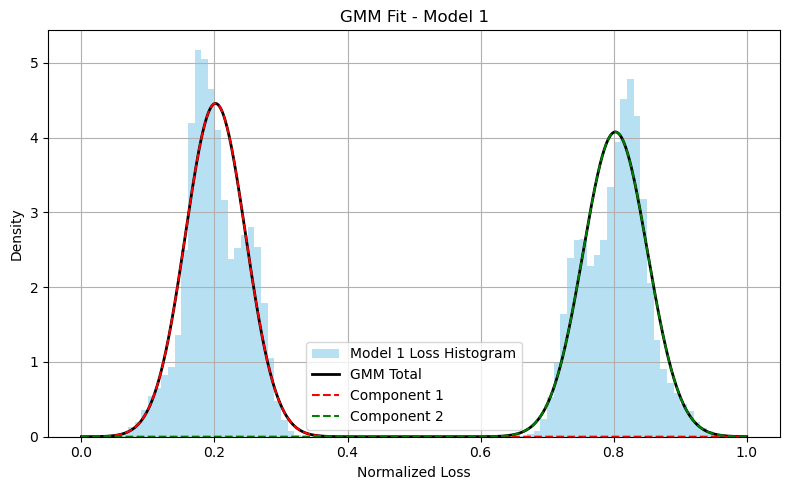

Component means (Model 2): [0.27718589 0.8089975 ]
Component weights (Model 2): [0.68097705 0.31902295]


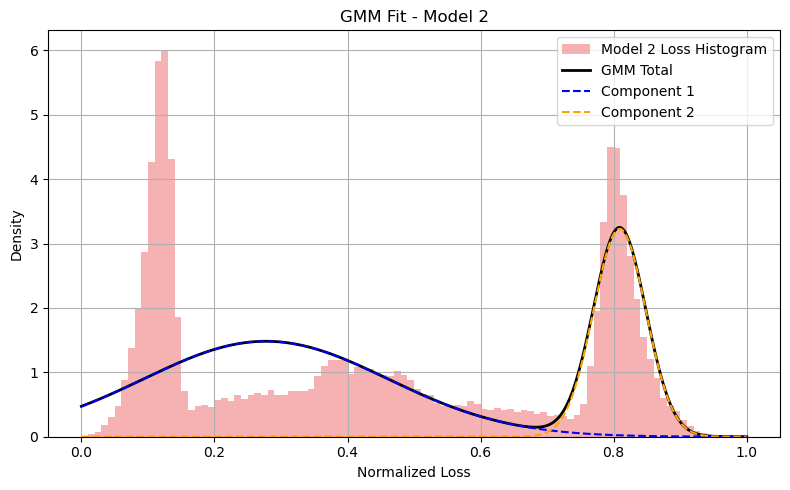

In [39]:
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

# Load losses
all_loss = pd.read_csv('dividemix_0.5_epoch_5_losses.csv')

# ---------- Model 1 ----------
losses1 = torch.tensor(all_loss['model1_loss'].values).view(-1, 1).numpy()
gmm1 = GaussianMixture(n_components=2, max_iter=10, tol=1e-2, random_state=42)
gmm1.fit(losses1)
print("Component means (Model 1):", gmm1.means_.flatten())
print("Component weights (Model 1):", gmm1.weights_.flatten())

x = np.linspace(0, 1, 1000).reshape(-1, 1)
log_prob1 = gmm1.score_samples(x)
pdf1 = np.exp(log_prob1)
responsibilities1 = gmm1.predict_proba(x)
component_pdfs1 = responsibilities1 * pdf1[:, np.newaxis]

plt.figure(figsize=(8, 5))
plt.hist(losses1, bins=100, density=True, alpha=0.6, color='skyblue', label="Model 1 Loss Histogram")
plt.plot(x, pdf1, label="GMM Total", color="black", linewidth=2)
plt.plot(x, component_pdfs1[:, 0], label="Component 1", linestyle='--', color='red')
plt.plot(x, component_pdfs1[:, 1], label="Component 2", linestyle='--', color='green')
plt.title("GMM Fit - Model 1")
plt.xlabel("Normalized Loss")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ---------- Model 2 ----------
losses2 = torch.tensor(all_loss['model2_loss'].values).view(-1, 1).numpy()
gmm2 = GaussianMixture(n_components=2, max_iter=10, tol=1e-2, random_state=42)
gmm2.fit(losses2)
print("Component means (Model 2):", gmm2.means_.flatten())
print("Component weights (Model 2):", gmm2.weights_.flatten())

log_prob2 = gmm2.score_samples(x)
pdf2 = np.exp(log_prob2)
responsibilities2 = gmm2.predict_proba(x)
component_pdfs2 = responsibilities2 * pdf2[:, np.newaxis]

plt.figure(figsize=(8, 5))
plt.hist(losses2, bins=100, density=True, alpha=0.6, color='lightcoral', label="Model 2 Loss Histogram")
plt.plot(x, pdf2, label="GMM Total", color="black", linewidth=2)
plt.plot(x, component_pdfs2[:, 0], label="Component 1", linestyle='--', color='blue')
plt.plot(x, component_pdfs2[:, 1], label="Component 2", linestyle='--', color='orange')
plt.title("GMM Fit - Model 2")
plt.xlabel("Normalized Loss")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [41]:
def plot_loss_histogram(losses, epoch, model):
    plt.figure(figsize=(6, 4))
    plt.hist(losses, bins=100, color='skyblue', alpha=0.7, edgecolor='black')
    plt.title(f"Loss Distribution At Epoch {epoch} for Model {model}")
    plt.xlabel("Normalized Loss")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
def fit_gmm_and_plot_histogram():
    epoch = 1
    for filename in os.listdir('.'):
        if filename.endswith('.csv'):
            # Load the CSV file
            df = pd.read_csv(filename)
            model1_loss = df['model1_loss'].values
            model2_loss = df['model2_loss'].values
            gmm_1 = GaussianMixture(n_components=2, max_iter=10, tol=1e-2, reg_covar=5e-4, random_state=42)
            gmm_2 = GaussianMixture(n_components=2, max_iter=10, tol=1e-2, reg_covar=5e-4, random_state=42)
            gmm_1.fit(model1_loss.reshape(-1, 1))
            gmm_2.fit(model2_loss.reshape(-1, 1))
            # Plot the loss histogram
            plot_loss_histogram(model1_loss, epoch, model='1')
            plot_loss_histogram(model2_loss, epoch, model='2')
            epoch += 1

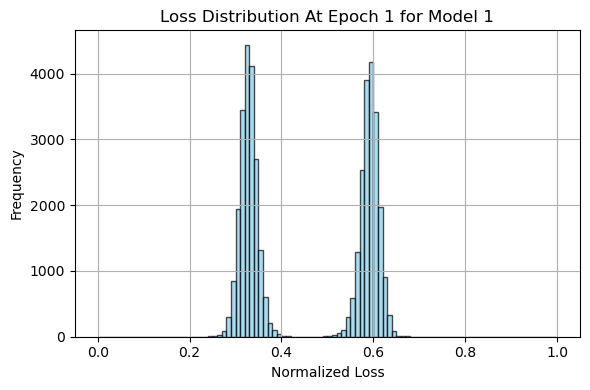

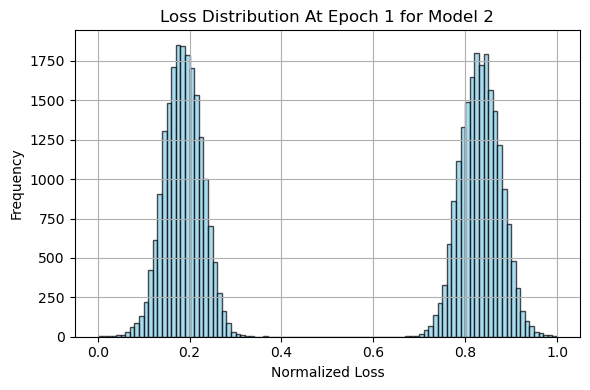

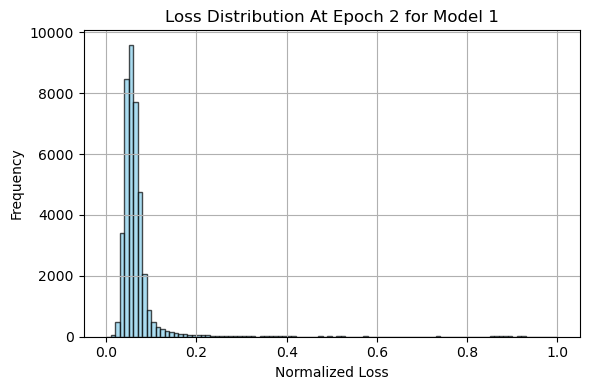

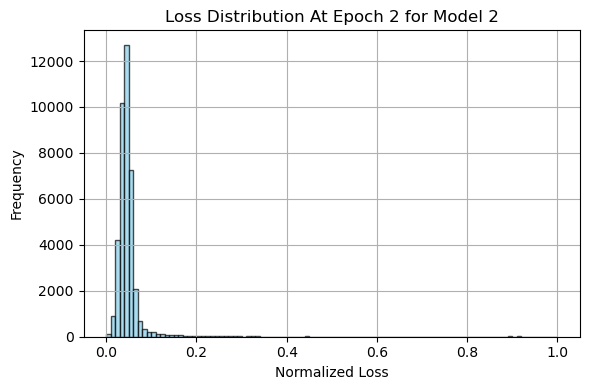

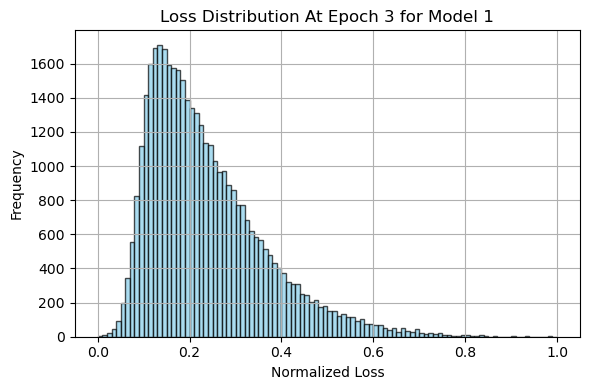

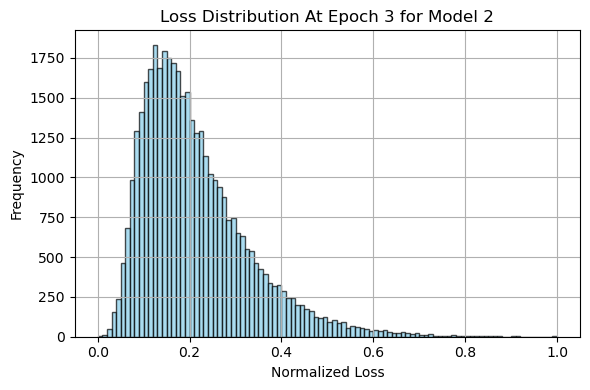

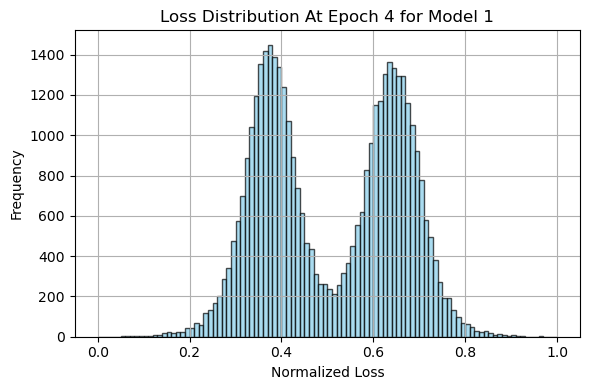

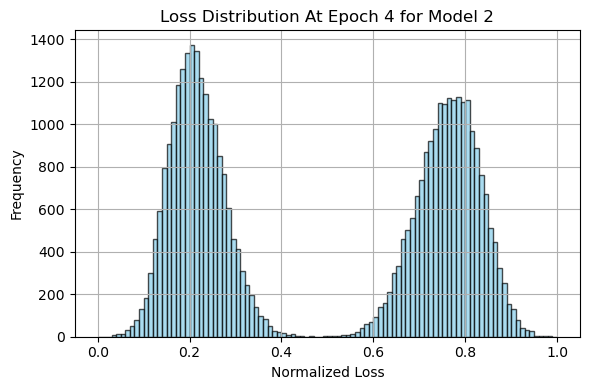

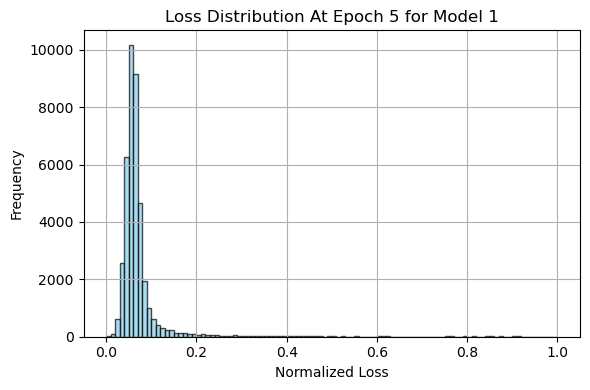

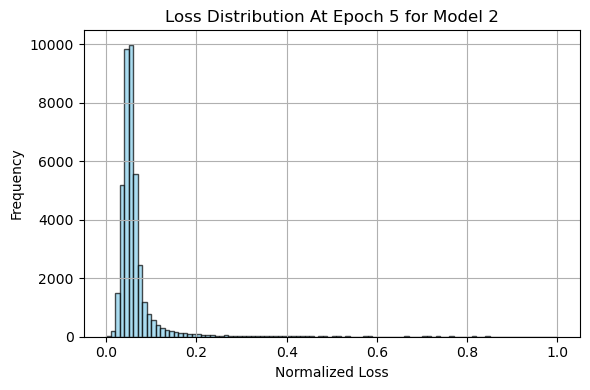

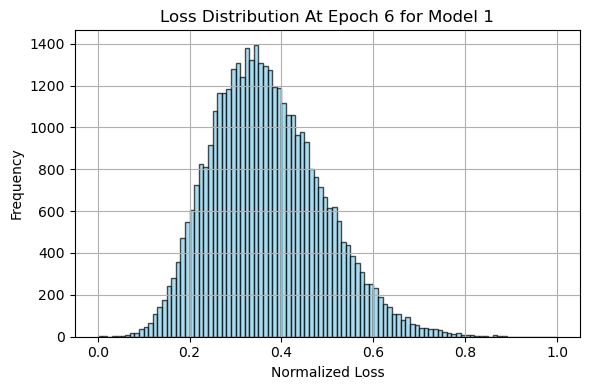

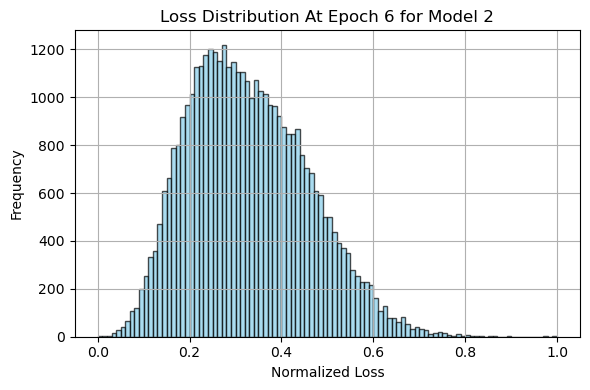

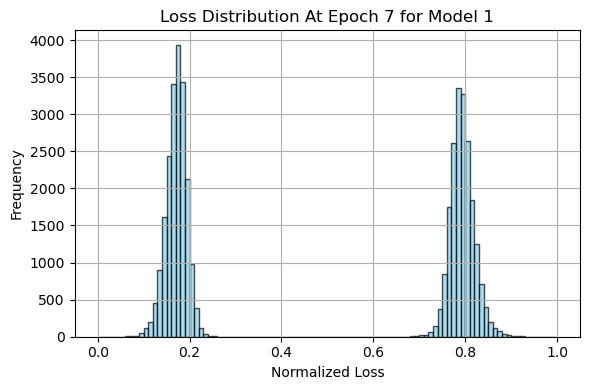

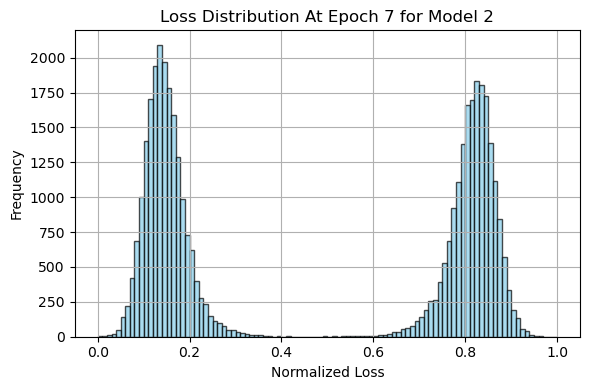

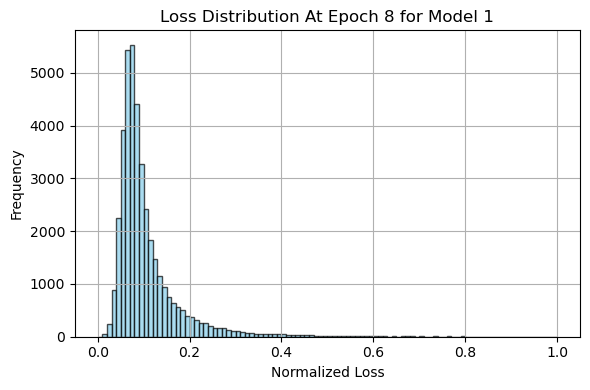

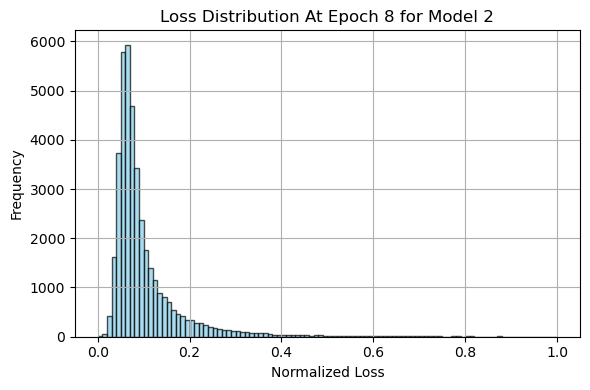

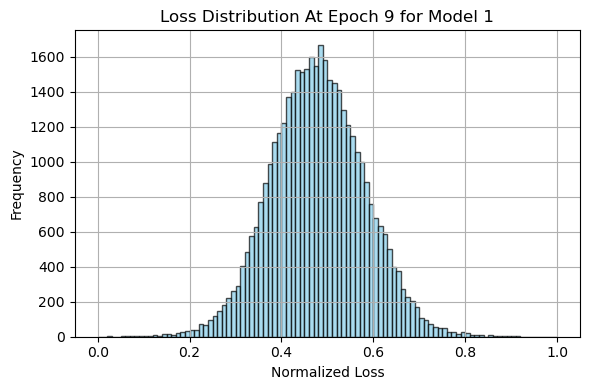

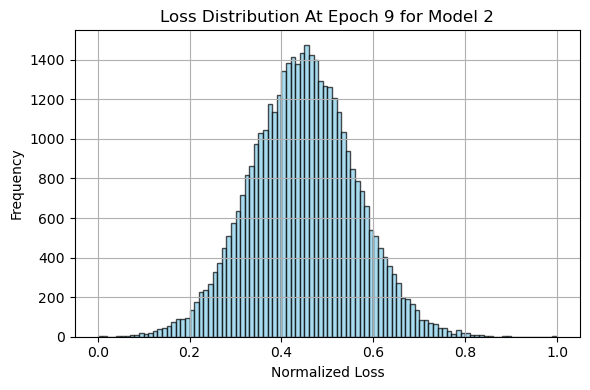

In [42]:
fit_gmm_and_plot_histogram()